# Task 3: Naive Bayes model using TF-IDF Vectors for Unigram+Bigram
## Import Librarires and Load Data


In [50]:
# ! pip install gemsim
import re
import time
import json
import emoji
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import nltk
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

In [2]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/prakashpun/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/prakashpun/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/prakashpun/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Get 100k data from the yelp_academic_dataset_review.json

In [3]:
input_file = "./yelp_academic_dataset/yelp_academic_dataset_review.json"
output_file = "yelp_review.csv"
subset_size = 100000

chunk_size = 10000
processed_rows = 0
subset_data = []

for chunk in pd.read_json(input_file, lines=True, chunksize=chunk_size):
    chunk = chunk[['stars', 'text']]
    
    subset_data.append(chunk)
    processed_rows += len(chunk)
    
    # Stop if we have enough data
    if processed_rows >= subset_size:
        break


subset_df = pd.concat(subset_data[:subset_size], ignore_index=True)
subset_df.to_csv(output_file, index=False)
print(f"Saved {subset_size} reviews to {output_file}")

Saved 100000 reviews to yelp_review.csv


In [4]:
df = pd.read_csv("yelp_review.csv")

In [5]:
df.head()

,stars,text
0,3,"If you decide to eat here, just be aware it is..."
1,5,I've taken a lot of spin classes over the year...
2,3,Family diner. Had the buffet. Eclectic assortm...
3,5,"Wow! Yummy, different, delicious. Our favo..."
4,4,Cute interior and owner (?) gave us tour of up...


In [6]:
df.isnull().sum()

stars    0
text     0
dtype: int64

In [7]:
df.describe()

,stars
count,100000.000000
mean,3.842910
std,1.354729
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


## Data Preprocessing

In [8]:
# Assuming df is your DataFrame containing the Yelp dataset
def map_stars_to_sentiment(stars):
    if stars >= 4:
        return 'Positive'
    elif stars == 3:
        return 'Neutral'
    else:
        return 'Negative'

# Add a new column 'sentiment'
df['sentiment'] = df['stars'].apply(map_stars_to_sentiment)

In [9]:
df = df.dropna(subset=['text'])

In [10]:
df.head()

,stars,text,sentiment
0,3,"If you decide to eat here, just be aware it is...",Neutral
1,5,I've taken a lot of spin classes over the year...,Positive
2,3,Family diner. Had the buffet. Eclectic assortm...,Neutral
3,5,"Wow! Yummy, different, delicious. Our favo...",Positive
4,4,Cute interior and owner (?) gave us tour of up...,Positive


In [11]:
sample_size = 100000
classes = ['Positive', 'Neutral', 'Negative']
samples_per_class = sample_size // len(classes)

df_sampled = df.groupby('sentiment', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), samples_per_class), random_state=42)
)

In [12]:
# balance classes by sampling
# sample_size = 20000  # Adjust as needed
# df = df.groupby('sentiment').apply(lambda x: x.sample(min(len(x), sample_size))).reset_index(drop=True)

## Check Class Distribution

In [13]:
df['sentiment'].value_counts()

sentiment
Positive    69729
Negative    18909
Neutral     11362
Name: count, dtype: int64

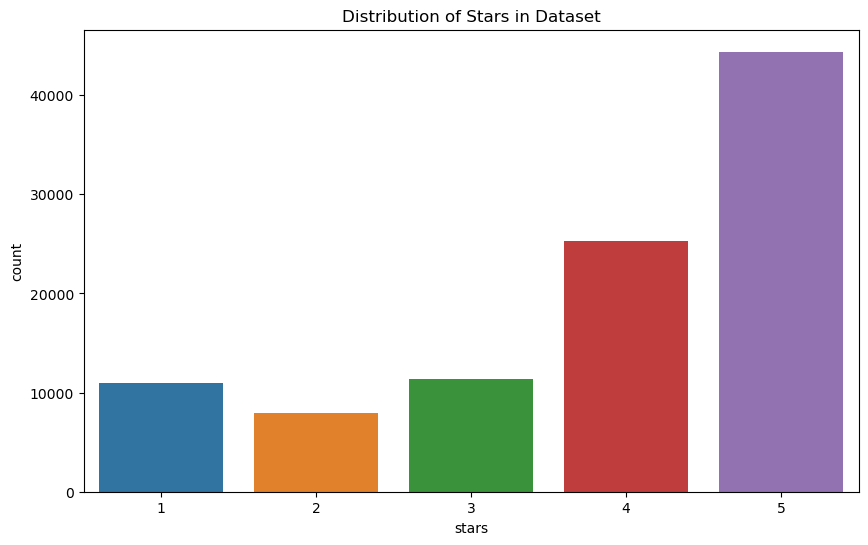

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(x='stars', data=df)
plt.title('Distribution of Stars in Dataset')
plt.show()

In [15]:
df_sampled.head()

,stars,text,sentiment
52533,2,I know that this place has been around forever...,Negative
52588,1,Why do I have to keep leaving updates? I spoke...,Negative
91257,1,I have never written a review before until now...,Negative
15635,1,"Asked for a trim and thinning out, got butcher...",Negative
36930,2,Been living in the area for 14yr. I'm used to ...,Negative


## Data Cleaning and Text Preprocessing

In [17]:
slang_dict = {
    "lol": "laugh out loud",
    "omg": "oh my god",
    "btw": "by the way",
    "idk": "i do not know",
    "imo": "in my opinion",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "rofl": "rolling on the floor laughing",
    "ily": "i love you",
    "thx": "thanks",
    "pls": "please",
    "u": "you",
    "r": "are",
    "2": "to",
    "4": "for",
    "gr8": "great",
    "b4": "before",
    "w/o": "without",
    "w/": "with",
    "afaik": "as far as i know",
    "ama": "ask me anything",
    "tbf": "to be fair",
    "yolo": "you only live once"
}

# Define a detailed preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove user mentions but keep hashtags (remove '#' but keep the text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    
    # Handle emojis (convert emojis to text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    
    # Handle abbreviations and contractions
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can\'t", "can not", text)
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    
    # Normalize slang using the slang dictionary
    words = text.split()
    words = [slang_dict[word] if word in slang_dict else word for word in words]
    text = " ".join(words)
    
    # Remove special characters and numbers
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d+', '', text)
    
    # Tokenize text
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatize words
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Join tokens back into a single string
    text = ' '.join(tokens)
    
    return text

In [18]:
df['cleaned_text'] = df['text'].apply(preprocess_text)

# Split Dataset

In [20]:
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['sentiment'], test_size=0.3, random_state=42)

In [21]:
X_train.head()

76513    super sweet group baristas amazing space best ...
60406    great deal choose buffet pay pound pound shabb...
27322    friendly great service food also good portion ...
53699    wanted come since opening afraid going packed ...
65412    okay gave lecada star staff extremely friendly...
Name: cleaned_text, dtype: object

In [22]:
y_train.head()

76513    Positive
60406     Neutral
27322    Positive
53699    Positive
65412    Negative
Name: sentiment, dtype: object

## Class Separability Check

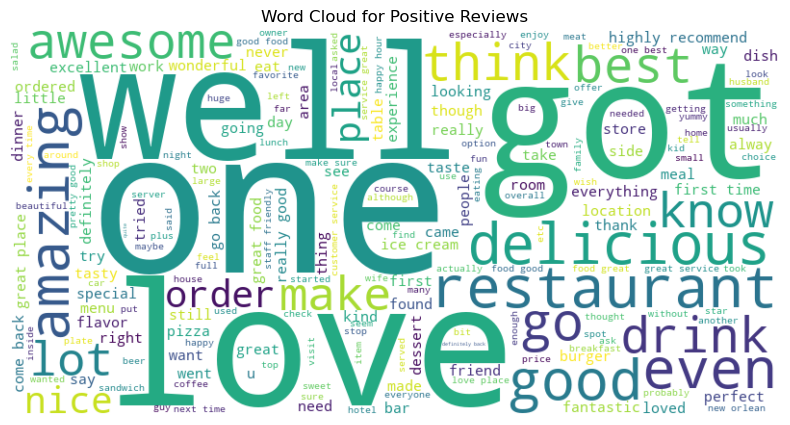

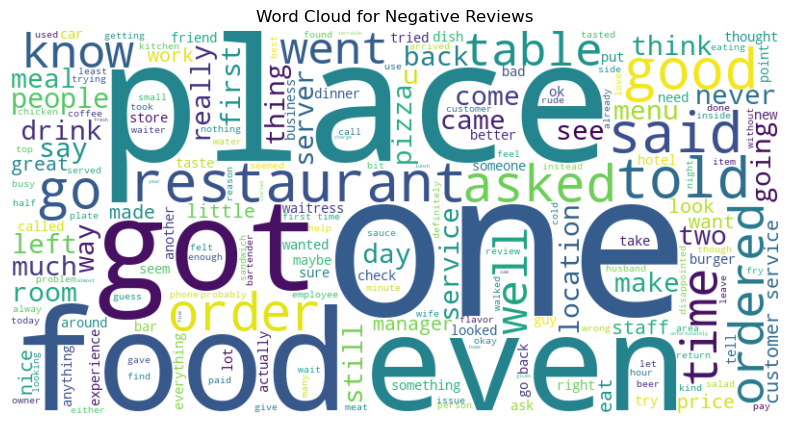

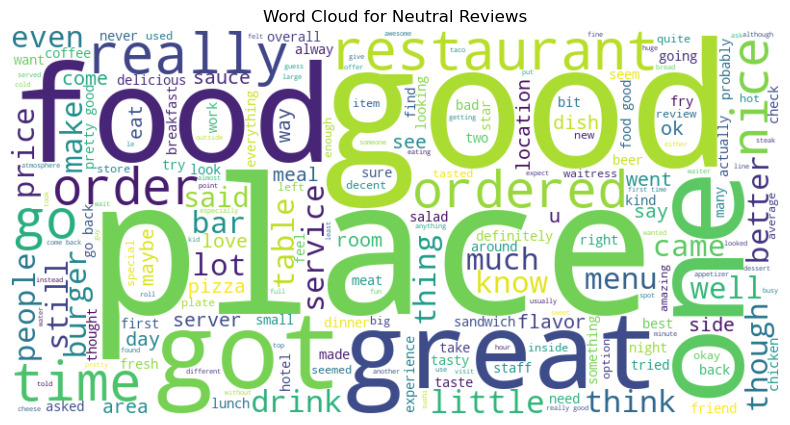

In [23]:
def plot_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Word cloud for Positive reviews
positive_text = ' '.join(df[df['sentiment'] == 'Positive']['cleaned_text'])
plot_word_cloud(positive_text, 'Word Cloud for Positive Reviews')

# Word cloud for Negative reviews
negative_text = ' '.join(df[df['sentiment'] == 'Negative']['cleaned_text'])
plot_word_cloud(negative_text, 'Word Cloud for Negative Reviews')

# Word cloud for Neutral reviews
neutral_text = ' '.join(df[df['sentiment'] == 'Neutral']['cleaned_text'])
plot_word_cloud(neutral_text, 'Word Cloud for Neutral Reviews')

## Model: Naive Bayes with Count Vectors (Unigram)

In [24]:
vectorizer = CountVectorizer(ngram_range=(1, 1), max_features=20000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [25]:
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0]}
nb_model = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='accuracy')
nb_model.fit(X_train_vec, y_train)

GridSearchCV(cv=5, estimator=MultinomialNB(),
             param_grid={'alpha': [0.01, 0.1, 1.0, 10.0]}, scoring='accuracy')

In [26]:
y_pred = nb_model.predict(X_test_vec)
print("Best alpha:", nb_model.best_params_)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Best alpha: {'alpha': 10.0}
              precision    recall  f1-score   support

    Negative       0.74      0.72      0.73      5617
     Neutral       0.43      0.05      0.10      3413
    Positive       0.83      0.96      0.89     20970

    accuracy                           0.81     30000
   macro avg       0.67      0.58      0.57     30000
weighted avg       0.77      0.81      0.77     30000

Confusion Matrix:
 [[ 4043   180  1394]
 [  640   185  2588]
 [  781    66 20123]]


In [27]:
# Plot ROC curve
y_prob = nb_model.predict_proba(X_test_vec)
roc_auc = roc_auc_score(pd.get_dummies(y_test), y_prob, multi_class='ovr')
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.8355717921615066


In [28]:
# Tuning
# Experiment with different values of max_features
# for max_feat in [10000, 20000, 30000, 50000]:
#     print(f"\nTesting max_features={max_feat}")
#     vectorizer = CountVectorizer(ngram_range=(1, 1), max_features=max_feat)
#     X_train_vec = vectorizer.fit_transform(X_train)
#     X_test_vec = vectorizer.transform(X_test)
    
#     nb_model = MultinomialNB(alpha=0.1)  # Use the best alpha from previous tuning
#     nb_model.fit(X_train_vec, y_train)
    
#     y_pred = nb_model.predict(X_test_vec)
#     print(classification_report(y_test, y_pred))
#     print("ROC AUC Score:", roc_auc_score(pd.get_dummies(y_test), nb_model.predict_proba(X_test_vec), multi_class='ovr'))

## SVM with TF-IDF Vectors (Unigram + Bigram)

In [29]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)  # Unigram + Bigram
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [31]:
param_grid = {'C': [1.0], 'kernel': ['linear']}
svm_model = SVC(kernel='linear', C=1.0)
start_time = time.time()
print(start_time)
svm_model.fit(X_train_vec, y_train)
end_time = time.time()
print(end_time)

1737853901.3225322
1737854625.8627992


In [33]:
# dump svm
with open('svm_model.pkl', 'wb') as file:
    pickle.dump(svm_model, file)

In [35]:
y_pred = svm_model.predict(X_test_vec)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.80      0.81      0.80      5617
     Neutral       0.53      0.28      0.37      3413
    Positive       0.90      0.96      0.93     20970

    accuracy                           0.86     30000
   macro avg       0.74      0.68      0.70     30000
weighted avg       0.84      0.86      0.84     30000

Confusion Matrix:
 [[ 4568   416   633]
 [  770   955  1688]
 [  398   425 20147]]


## Naive Bayes model using TF-IDF Vectors for Unigram+Bigram

In [64]:
# nb_vectorizer = TfidfVectorizer(ngram_range=(1, 2), binary=True)
vectorizer_bigram = TfidfVectorizer(ngram_range=(1, 2))
X_train_vec_bigram = vectorizer_bigram.fit_transform(X_train)
X_test_vec_bigram = vectorizer_bigram.transform(X_test)

In [65]:
X_train_vec_bigram.shape

(70000, 1487270)

In [66]:
X_test_vec_bigram.shape

(30000, 1487270)

In [67]:
start_time = time.time()
nb_model_bigram = MultinomialNB(alpha=1.0)
# Train the model
nb_model_bigram.fit(X_train_vec_bigram, y_train)
train_time_bigram = time.time() - start_time

# Evaluate the model
y_pred_bigram = nb_model_bigram.predict(X_test_vec_bigram)
print("Classification Report:\n", classification_report(y_test, y_pred_bigram))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bigram))

# Plot ROC curve
y_prob_bigram = nb_model_bigram.predict_proba(X_test_vec_bigram)
roc_auc = roc_auc_score(pd.get_dummies(y_test), y_prob_bigram, multi_class='ovr')
print("ROC AUC Score:", roc_auc)
print("Train Time", train_time_bigram)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification Report:
               precision    recall  f1-score   support

    Negative       0.95      0.01      0.02      5617
     Neutral       0.00      0.00      0.00      3413
    Positive       0.70      1.00      0.82     20970

    accuracy                           0.70     30000
   macro avg       0.55      0.34      0.28     30000
weighted avg       0.67      0.70      0.58     30000

Confusion Matrix:
 [[   58     0  5559]
 [    3     0  3410]
 [    0     0 20970]]
ROC AUC Score: 0.7666899688020683
Train Time 0.1557450294494629


## Tuning for Naive Bayes

In [68]:
# Define the parameter grid
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0]}

# Perform grid search
grid_search = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_vec_bigram, y_train)

# Print the best parameters
print("Best alpha:", grid_search.best_params_)

# Evaluate the best model
best_nb_model = grid_search.best_estimator_
y_pred = best_nb_model.predict(X_test_vec)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Plot ROC curve
y_prob = best_nb_model.predict_proba(X_test_vec_bigram)
roc_auc = roc_auc_score(pd.get_dummies(y_test), y_prob, multi_class='ovr')
print("ROC AUC Score:", roc_auc)

Best alpha: {'alpha': 0.1}
Classification Report:
               precision    recall  f1-score   support

    Negative       0.92      0.48      0.63      5617
     Neutral       0.62      0.00      0.00      3413
    Positive       0.77      1.00      0.87     20970

    accuracy                           0.79     30000
   macro avg       0.77      0.49      0.50     30000
weighted avg       0.78      0.79      0.73     30000

Confusion Matrix:
 [[ 2692     3  2922]
 [  176     5  3232]
 [   60     0 20910]]
ROC AUC Score: 0.8708649299402689


## Feature Importance

In [69]:
# Get feature names (words or bigrams)
feature_names = vectorizer_bigram.get_feature_names_out()

# Get log probabilities for each class
log_probabilities = best_nb_model.feature_log_prob_

# Visualize top 10 features for each class
for i, class_label in enumerate(best_nb_model.classes_):
    print(f"\nTop 10 features for class '{class_label}':")
    top_features = np.argsort(log_probabilities[i])[-10:]  # Get indices of top 10 features
    for feature_idx in top_features:
        print(f"{feature_names[feature_idx]}: {log_probabilities[i][feature_idx]:.4f}")


Top 10 features for class 'Negative':
back: -7.5700
order: -7.5477
get: -7.5461
one: -7.5381
like: -7.5212
service: -7.4210
place: -7.3980
time: -7.3931
would: -7.3483
food: -7.0893

Top 10 features for class 'Neutral':
great: -7.9795
get: -7.9705
really: -7.9135
time: -7.8239
service: -7.8087
like: -7.7646
would: -7.6368
place: -7.5758
food: -7.3181
good: -7.1385

Top 10 features for class 'Positive':
friendly: -7.1658
delicious: -7.1407
love: -7.0990
best: -7.0715
time: -7.0064
service: -6.9165
good: -6.6263
food: -6.5974
place: -6.5822
great: -6.3530


## Cross-validation

In [74]:
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0]}
grid_search = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_vec_bigram, y_train)

# Print the best parameters
print("\nBest alpha:", grid_search.best_params_)

# Evaluate the best model
best_nb_model = grid_search.best_estimator_
y_pred_best = best_nb_model.predict(X_test_vec_bigram)
print("Classification Report (Best Model):\n", classification_report(y_test, y_pred_best))
print("Confusion Matrix (Best Model):\n", confusion_matrix(y_test, y_pred_best))
print("AUC (Best Model):", roc_auc_score(pd.get_dummies(y_test), best_nb_model.predict_proba(X_test_vec_bigram), multi_class='ovr'))
print("Accuracy (Best Model):", np.mean(y_pred_best == y_test))


Best alpha: {'alpha': 0.1}
Classification Report (Best Model):
               precision    recall  f1-score   support

    Negative       0.92      0.48      0.63      5617
     Neutral       0.62      0.00      0.00      3413
    Positive       0.77      1.00      0.87     20970

    accuracy                           0.79     30000
   macro avg       0.77      0.49      0.50     30000
weighted avg       0.78      0.79      0.73     30000

Confusion Matrix (Best Model):
 [[ 2692     3  2922]
 [  176     5  3232]
 [   60     0 20910]]
AUC (Best Model): 0.8708649299402689
Accuracy (Best Model): 0.7869


In [75]:
print("\nInterpretability: Top Features for Each Class")
for i, class_label in enumerate(nb_model_bigram.classes_):
    print(f"\nClass '{class_label}':")
    top_features = np.argsort(log_probabilities[i])[-5:]  # Top 5 features
    for feature_idx in top_features:
        print(f"{feature_names[feature_idx]}: {log_probabilities[i][feature_idx]:.4f}")


Interpretability: Top Features for Each Class

Class 'Negative':
service: -7.4210
place: -7.3980
time: -7.3931
would: -7.3483
food: -7.0893

Class 'Neutral':
like: -7.7646
would: -7.6368
place: -7.5758
food: -7.3181
good: -7.1385

Class 'Positive':
service: -6.9165
good: -6.6263
food: -6.5974
place: -6.5822
great: -6.3530


In [70]:
with open('naive_bayes_model.pkl', 'wb') as file:
    pickle.dump(best_nb_model, file)

with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

print("Model and vectorizer saved.")

Model and vectorizer saved.


In [76]:
with open('naive_bayes_model.pkl', 'rb') as file:
    loaded_nb_model = pickle.load(file)

with open('tfidf_vectorizer.pkl', 'rb') as file:
    loaded_vectorizer = pickle.load(file)

X_test_vec_loaded = loaded_vectorizer.transform(X_test)
y_pred_loaded = loaded_nb_model.predict(X_test_vec_loaded)

print("Classification Report:\n", classification_report(y_test, y_pred_loaded))

Classification Report:
               precision    recall  f1-score   support

    Negative       0.92      0.48      0.63      5617
     Neutral       0.62      0.00      0.00      3413
    Positive       0.77      1.00      0.87     20970

    accuracy                           0.79     30000
   macro avg       0.77      0.49      0.50     30000
weighted avg       0.78      0.79      0.73     30000

